In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [13]:

seeds = [3, 4, 5, 6, 7]
metrics = ["AUC-PR", "AUC-ROC", "Standard-F1"]

dfs = []
for seed in seeds:
    df = pd.read_csv(f"../results/AutoEncoder/paper_run_stride_{seed}.csv")
    df["seed"] = seed  
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

avg_df = (
    full_df
    .groupby("stride")[["AUC-PR", "AUC-ROC", "Standard-F1", "execution_time"]]
    .mean()
    .reset_index()
)
avg_df[metrics] = avg_df[metrics].round(2)
print(avg_df)

   stride  AUC-PR  AUC-ROC  Standard-F1  execution_time
0       1    0.47     0.86         0.51        0.225311
1      12    0.46     0.85         0.49        0.017564
2      24    0.44     0.84         0.48        0.009082
3      36    0.43     0.82         0.47        0.006620
4      48    0.42     0.82         0.45        0.005416
5      60    0.40     0.80         0.44        0.004435
6      72    0.39     0.79         0.43        0.004129
7      84    0.38     0.78         0.42        0.003598
8      96    0.37     0.78         0.41        0.003561


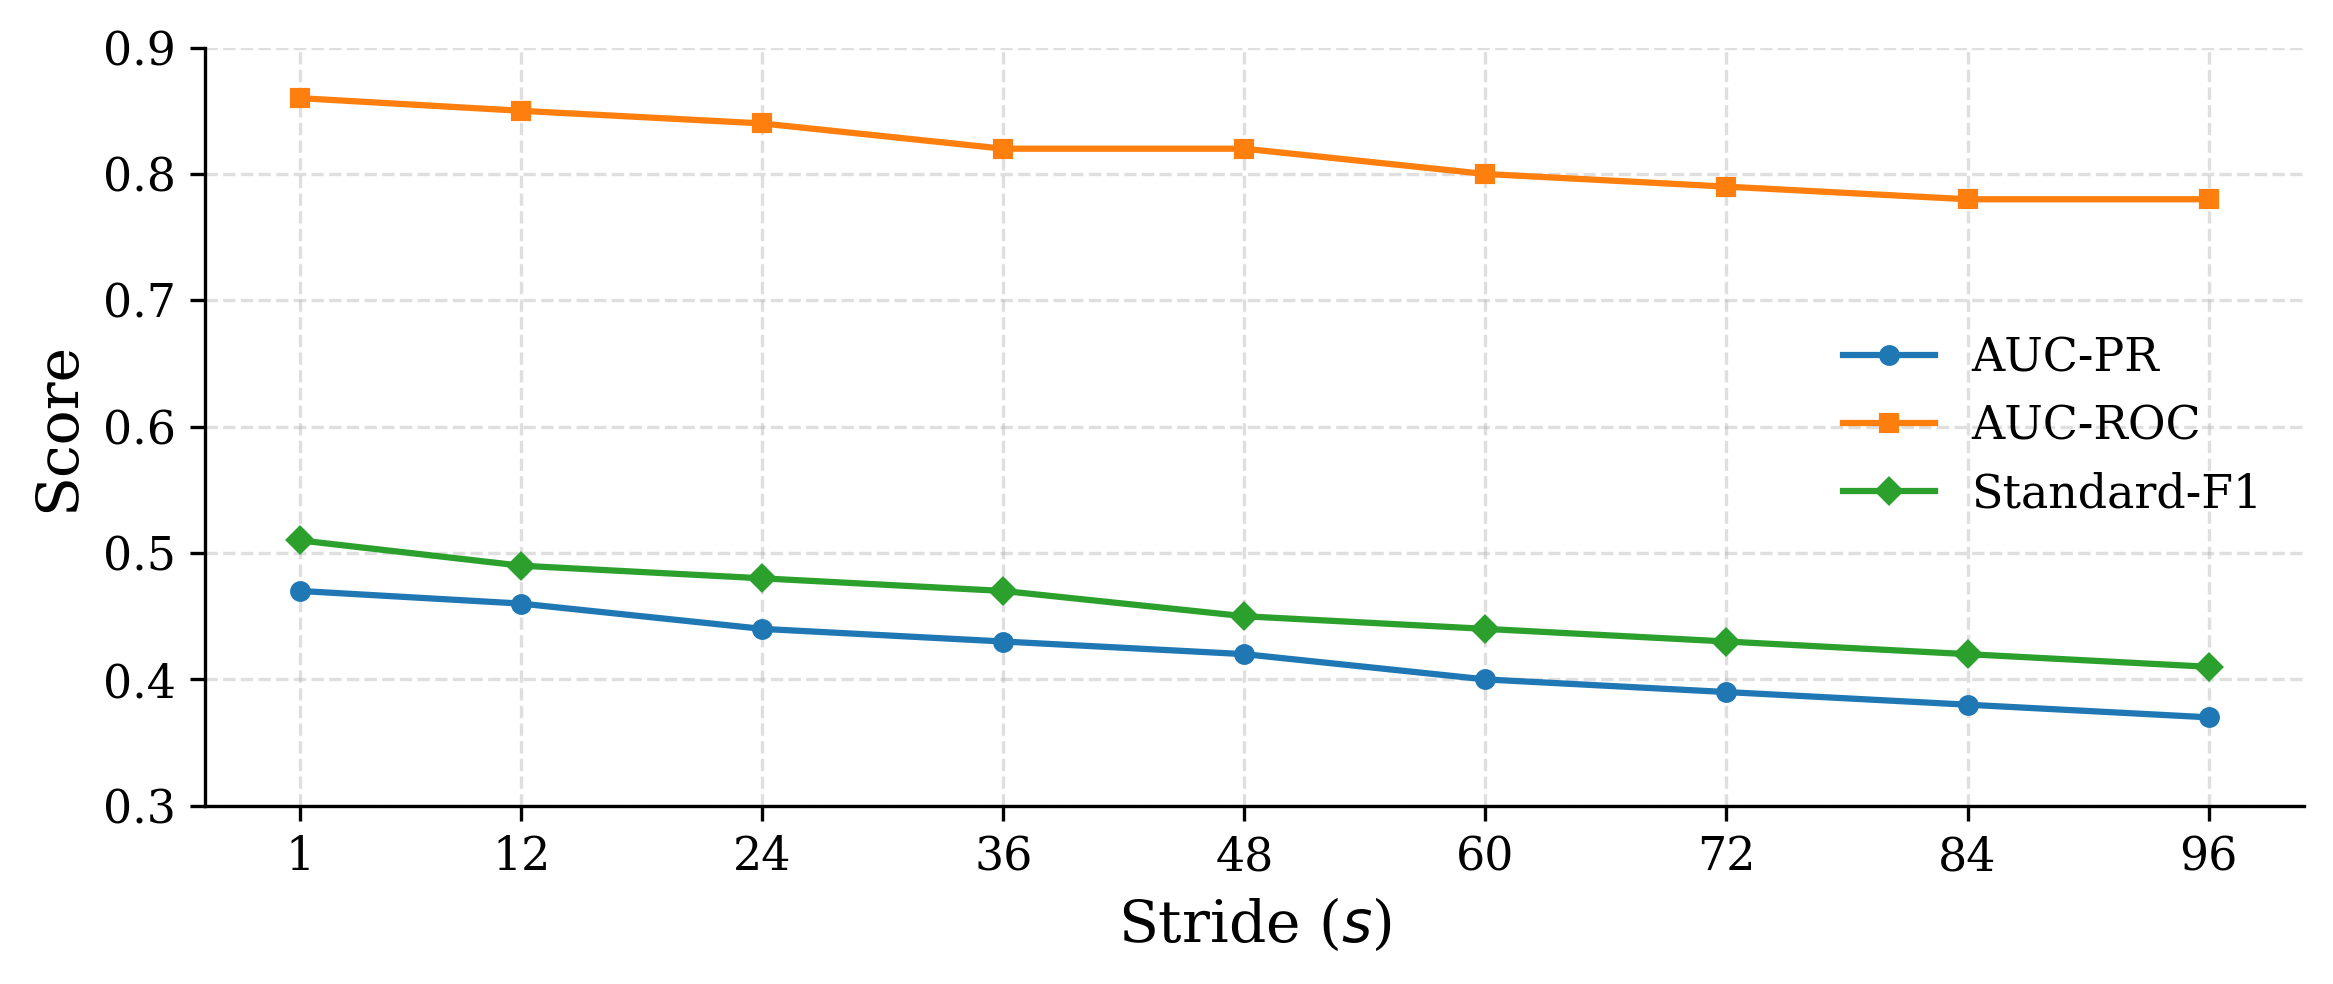

In [14]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300
})
metrics = ["AUC-PR", "AUC-ROC", "Standard-F1"]

fig, ax = plt.subplots(figsize=(8, 3.5))

markers = ['o', 's', 'D']

for metric, marker in zip(metrics, markers):
    ax.plot(
        avg_df["stride"],
        avg_df[metric],
        marker=marker,
        markersize=4,
        label=metric
    )
strides = sorted(avg_df["stride"].unique())
ax.set_xticks(strides)
ax.set_xticklabels([str(s) for s in strides])
ax.set_xlabel("Stride ($s$)")
ax.set_ylabel("Score")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.ylim(0.3, 0.9)
plt.tight_layout()

plt.savefig("../Figures/stride_impact.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()

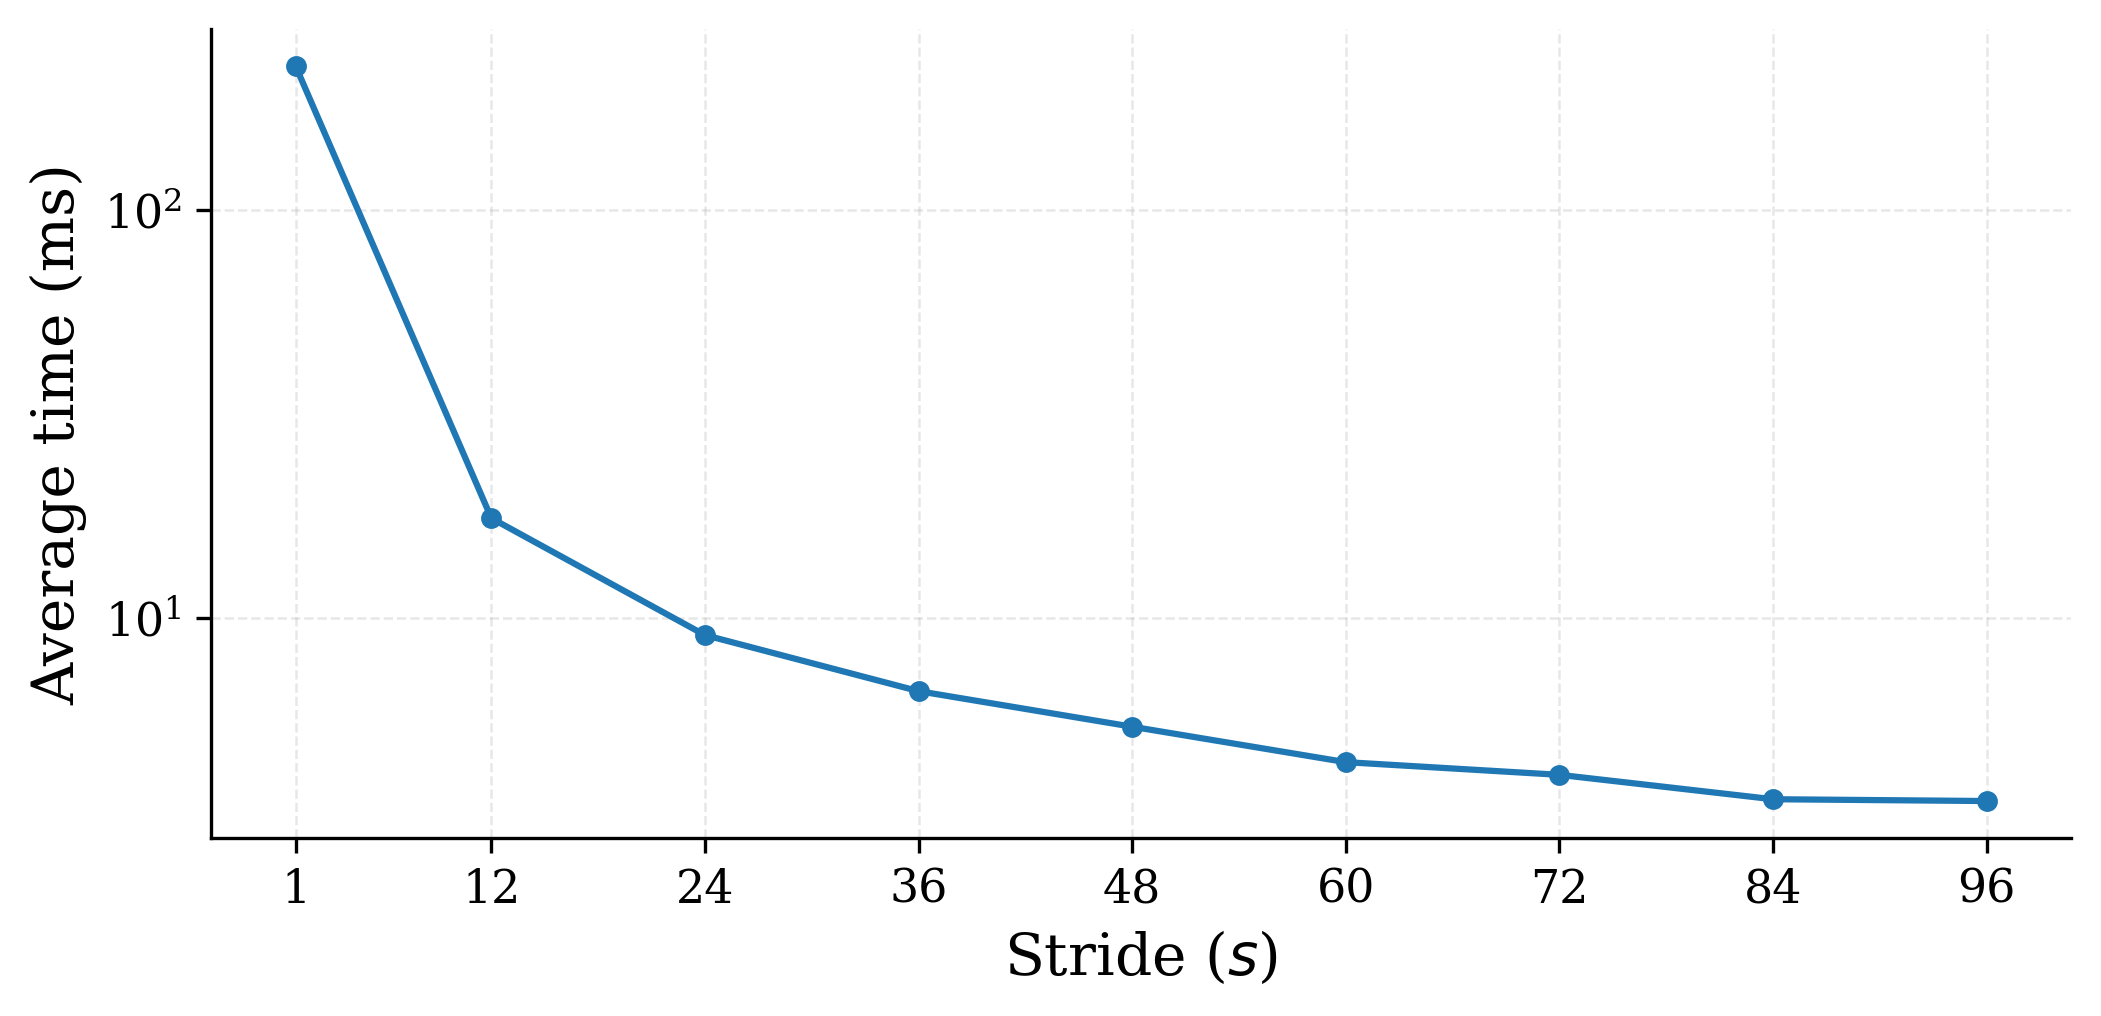

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.plot(
    avg_df["stride"],
    avg_df["execution_time"] * 1000 ,
    marker='o',
    markersize=4
)

strides = sorted(avg_df["stride"].unique())
ax.set_xticks(strides)
ax.set_xticklabels([str(s) for s in strides])

ax.set_xlabel("Stride ($s$)")
ax.set_ylabel("Average time (ms)")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yscale("log")

ax.grid(True, which="major", linestyle="--", alpha=0.3, linewidth=0.6)
ax.yaxis.set_minor_locator(mticker.NullLocator())


# Save
plt.savefig("../Figures/execution_time.pdf", format="pdf", bbox_inches="tight", pad_inches=0)

plt.show()